# Phishing Website Detection — Exploratory Data Analysis (EDA)

**Goal of this notebook:** understand the phishing-website dataset *before* we build any model — its structure, quality, class balance, how each feature relates to the target, and which problems (duplicates, redundancy, near-constant features) we must handle in the model-training notebook (`02_model_training.ipynb`).

**About the data.** Each row is one website described by **30 features** that were extracted from its URL, HTML/JavaScript source and domain information, plus a target column `Result`.

| Value | Meaning in a feature column | Meaning in `Result` |
|:---:|---|---|
| `1`  | looks **legitimate** | **Legitimate** website |
| `0`  | **suspicious** / unclear | — |
| `-1` | looks like **phishing** | **Phishing** website |

> This is the convention documented for the well-known UCI *Website Phishing* dataset. We will **verify it with the data** in Section 8 instead of just trusting it (a few features, e.g. `Redirect`, are coded differently).

**Feature groups (from the original dataset description)**

| Group | Features |
|---|---|
| Address-bar based | `having_IP_Address`, `URL_Length`, `Shortining_Service`, `having_At_Symbol`, `double_slash_redirecting`, `Prefix_Suffix`, `having_Sub_Domain`, `SSLfinal_State`, `Domain_registeration_length`, `Favicon`, `port`, `HTTPS_token` |
| Abnormal-behaviour based | `Request_URL`, `URL_of_Anchor`, `Links_in_tags`, `SFH`, `Submitting_to_email`, `Abnormal_URL` |
| HTML / JavaScript based | `Redirect`, `on_mouseover`, `RightClick`, `popUpWidnow`, `Iframe` |
| Domain based | `age_of_domain`, `DNSRecord`, `web_traffic`, `Page_Rank`, `Google_Index`, `Links_pointing_to_page`, `Statistical_report` |

*(Some column names contain typos in the original data — `Shortining_Service`, `Domain_registeration_length`, `popUpWidnow`. We keep them unchanged so the notebook matches your file.)*

**Notebook roadmap:** 1 Setup → 2 Load → 3 Structure & quality → 4 Feature types → 5 Target balance → 6 Feature distributions → 7 Feature vs target → 8 Direction check → 9 Feature importance signals → 10 Correlation → 11 Duplicates → 12 Combined suspicion score → 13 PCA view → 14 Feature interactions → 15 Summary.

## 1. Setup — imports and plotting style

**What we do:** import the libraries used throughout the notebook and define one colour scheme (red = phishing, green = legitimate) so every plot is read the same way.

**Why:** consistent colours make the many plots later on much easier to interpret. Update `DATA_PATH` if your CSV lives elsewhere.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA_FILE = Path("Network_data") / "phisingData.csv"
search_roots = [Path.cwd(), *Path.cwd().parents]
DATA_PATH = next((root / DATA_FILE for root in search_roots if (root / DATA_FILE).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Could not find {DATA_FILE} from {Path.cwd()} or its parent directories")

LABELS  = {-1: "Phishing", 1: "Legitimate"}
PALETTE = {-1: "#e4572e", 1: "#2a9d8f"}                # numeric target -> colour
PALETTE_NAMES = {"Phishing": "#e4572e", "Legitimate": "#2a9d8f"}   # label name -> colour

## 2. Load the data and take a first look

**What we do:** read the CSV and print its shape and first rows.

**Why:** the very first sanity check — did the file load correctly, how many rows/columns are there, and do the values look like what we expect?

In [10]:
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c != "Result"]

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}  ({len(feature_cols)} features + 1 target)")
df.head()

Rows: 11,055 | Columns: 31  (30 features + 1 target)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


> **What we get:** the file has **11,055 websites × 31 columns** (30 features + `Result`). Every value is a small integer (`-1`, `0`, `1`) — the features are already numerically coded, so there is no text or date parsing to do.

## 3. Structure and data quality

### 3.1 Data types and memory
**What we do:** `df.info()` lists each column's dtype and non-null count.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  int64
 14  L

> **What we get:** all 31 columns are `int64` with **11,055 non-null values each** — there are no missing cells and no columns that need type conversion. Memory use is small (~2.6 MB), so every model in the next notebook will train quickly.

### 3.2 Missing values and duplicated rows
**What we do:** count null cells and fully duplicated rows.

**Why:** missing values would need imputation; duplicates would let the *same* sample appear in both the training and test set (data leakage) and inflate model scores.

In [12]:
print("Total missing values :", int(df.isnull().sum().sum()))
n_dup = df.duplicated().sum()
print(f"Duplicated rows      : {n_dup:,}  ({n_dup / len(df):.1%} of all rows)")
print(f"Unique rows          : {len(df) - n_dup:,}")

Total missing values : 0
Duplicated rows      : 5,206  (47.1% of all rows)
Unique rows          : 5,849


> **What we get:** no missing values at all, **but 5,206 rows (47.1 %) are exact duplicates** — only 5,849 rows are unique. This is the biggest data-quality issue in the dataset. Because the features are only a few discrete levels, many different websites collapse into the same feature vector. We will handle this before splitting the data (see Section 11).

## 4. Feature types — what kind of variables are these?

**What we do:** for every feature list how many distinct values it has and which ones.

**Why:** the dtype says `int64` for everything, but that's misleading. These are **categorical codes** (`-1`, `0`, `1`), not real measurements. This decides how we encode them later: the numbers have an order but *no meaningful distance* (is "suspicious" really exactly half-way between "phishing" and "legitimate"?).

In [13]:
type_summary = pd.DataFrame({
    "n_unique": df[feature_cols].nunique(),
    "values":   [sorted(df[c].unique().tolist()) for c in feature_cols],
})
type_summary["kind"] = np.where(type_summary["n_unique"] == 2, "binary", "tri-state")
display(type_summary)
print(type_summary["kind"].value_counts().to_string())
print("\nTarget values:", sorted(df["Result"].unique().tolist()))

,n_unique,values,kind
having_IP_Address,2,"[-1, 1]",binary
URL_Length,3,"[-1, 0, 1]",tri-state
Shortining_Service,2,"[-1, 1]",binary
having_At_Symbol,2,"[-1, 1]",binary
double_slash_redirecting,2,"[-1, 1]",binary
Prefix_Suffix,2,"[-1, 1]",binary
having_Sub_Domain,3,"[-1, 0, 1]",tri-state
SSLfinal_State,3,"[-1, 0, 1]",tri-state
Domain_registeration_length,2,"[-1, 1]",binary
Favicon,2,"[-1, 1]",binary


kind
binary       22
tri-state     8

Target values: [-1, 1]


> **What we get:**
> * **22 binary** features and **8 tri-state** features (`URL_Length`, `having_Sub_Domain`, `SSLfinal_State`, `URL_of_Anchor`, `Links_in_tags`, `SFH`, `web_traffic`, `Links_pointing_to_page`).
> * `Redirect` is coded **`0/1`** while all other binary features are coded `-1/1` — a small inconsistency in the source data that doesn't matter for models but explains why it looked different earlier.
> * The target has exactly two values (`-1` phishing, `1` legitimate) → a **binary classification** problem.
> * Since these are categorical codes, "encoding" in the model notebook means choosing *how* to present them to each algorithm (raw codes for trees, one-hot for linear/distance-based models).

## 5. Target distribution (class balance)

**What we do:** count phishing vs legitimate rows and plot them.

**Why:** strong class imbalance would force us to use special techniques (class weights, resampling, PR-AUC). A balanced target lets us use accuracy, F1 and ROC-AUC comfortably.

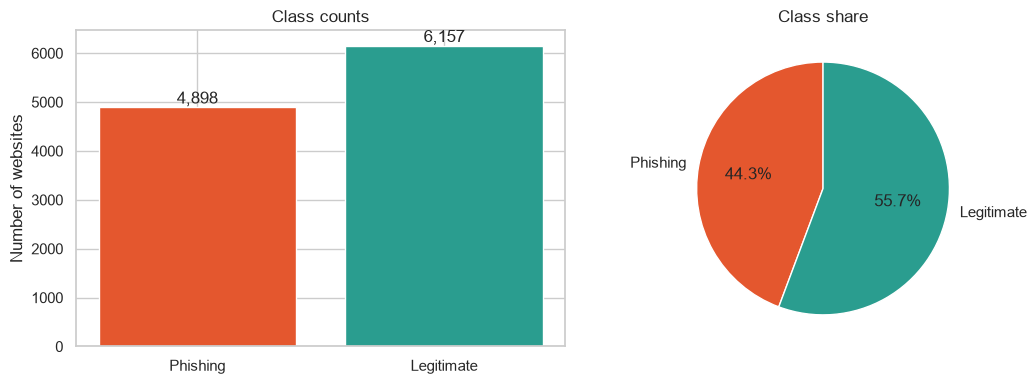

Result
Phishing      0.443
Legitimate    0.557


In [14]:
target_counts = df["Result"].value_counts().sort_index()
names  = [LABELS[i] for i in target_counts.index]
colors = [PALETTE[i] for i in target_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, target_counts.values, color=colors)
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}")
axes[0].set_title("Class counts"); axes[0].set_ylabel("Number of websites")
axes[1].pie(target_counts.values, labels=names, colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class share")
plt.tight_layout(); plt.show()

print((target_counts / len(df)).rename(index=LABELS).round(3).to_string())

> **What we get:** **4,898 phishing (44.3 %)** vs **6,157 legitimate (55.7 %)**. The classes are only mildly unbalanced, so **no resampling (SMOTE / under-sampling) is required**. We will still use a *stratified* split so both sets keep the same class ratio, and judge models on F1 and ROC-AUC as well as accuracy.

## 6. Feature distributions

**What we do:** draw a heat-map showing, for every feature, the percentage of rows that take each value (`-1`, `0`, `1`); then list the most one-sided features.

**Why:** a feature that is almost always the same value carries very little information and can behave like noise. This plot also shows which features have a "suspicious" (`0`) level at all.

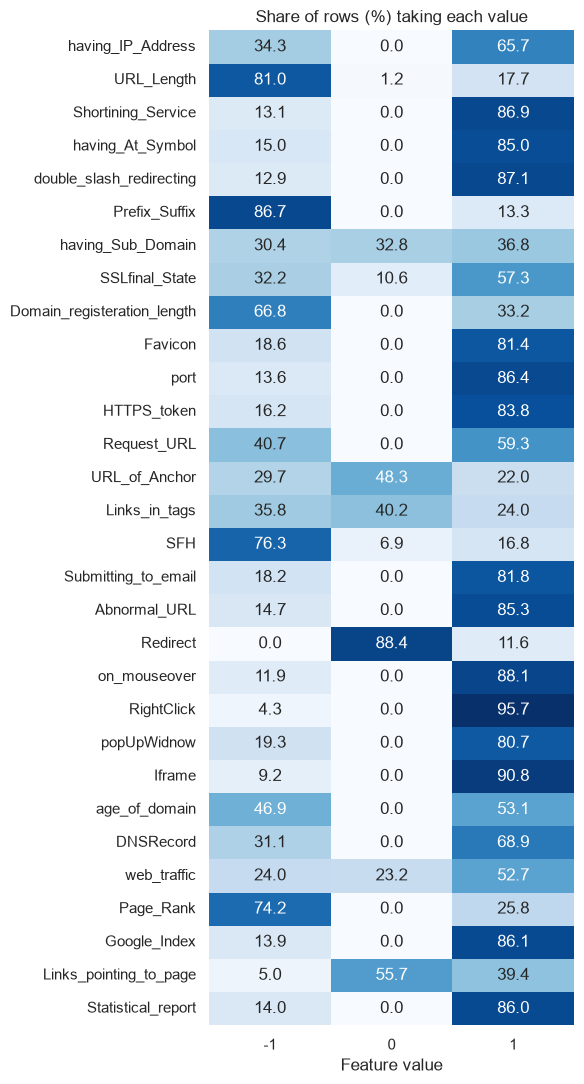

Most one-sided features (% of rows in the most common value):
RightClick                  95.7
Iframe                      90.8
Redirect                    88.4
on_mouseover                88.1
double_slash_redirecting    87.1
Shortining_Service          86.9
Prefix_Suffix               86.7
port                        86.4


In [15]:
value_dist = (df[feature_cols].apply(lambda s: s.value_counts(normalize=True)).T.fillna(0) * 100)[[-1, 0, 1]]

fig, ax = plt.subplots(figsize=(6, 11))
sns.heatmap(value_dist, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Share of rows (%) taking each value")
ax.set_xlabel("Feature value"); plt.tight_layout(); plt.show()

dominant = value_dist.max(axis=1).sort_values(ascending=False)
print("Most one-sided features (% of rows in the most common value):")
print(dominant.head(8).round(1).to_string())

> **What we get:** several features are heavily one-sided — `RightClick` (95.7 % the same value), `Iframe` (90.8 %), `Redirect` (88.4 %), `on_mouseover` (88.1 %) and more. Only a few features (e.g. `SSLfinal_State`, `URL_of_Anchor`, `web_traffic`, `having_Sub_Domain`) are spread across all their values. Near-constant features have little chance to separate the classes; the next sections check whether that's true.

## 7. Feature vs target

### 7.1 Class counts inside every feature value
**What we do:** for each of the 30 features draw a count-plot split by class (red = phishing, green = legitimate).

**Why:** this is the most direct way to *see* which features separate the two classes — where the red and green bars are very different in height for a given value, the feature is informative.

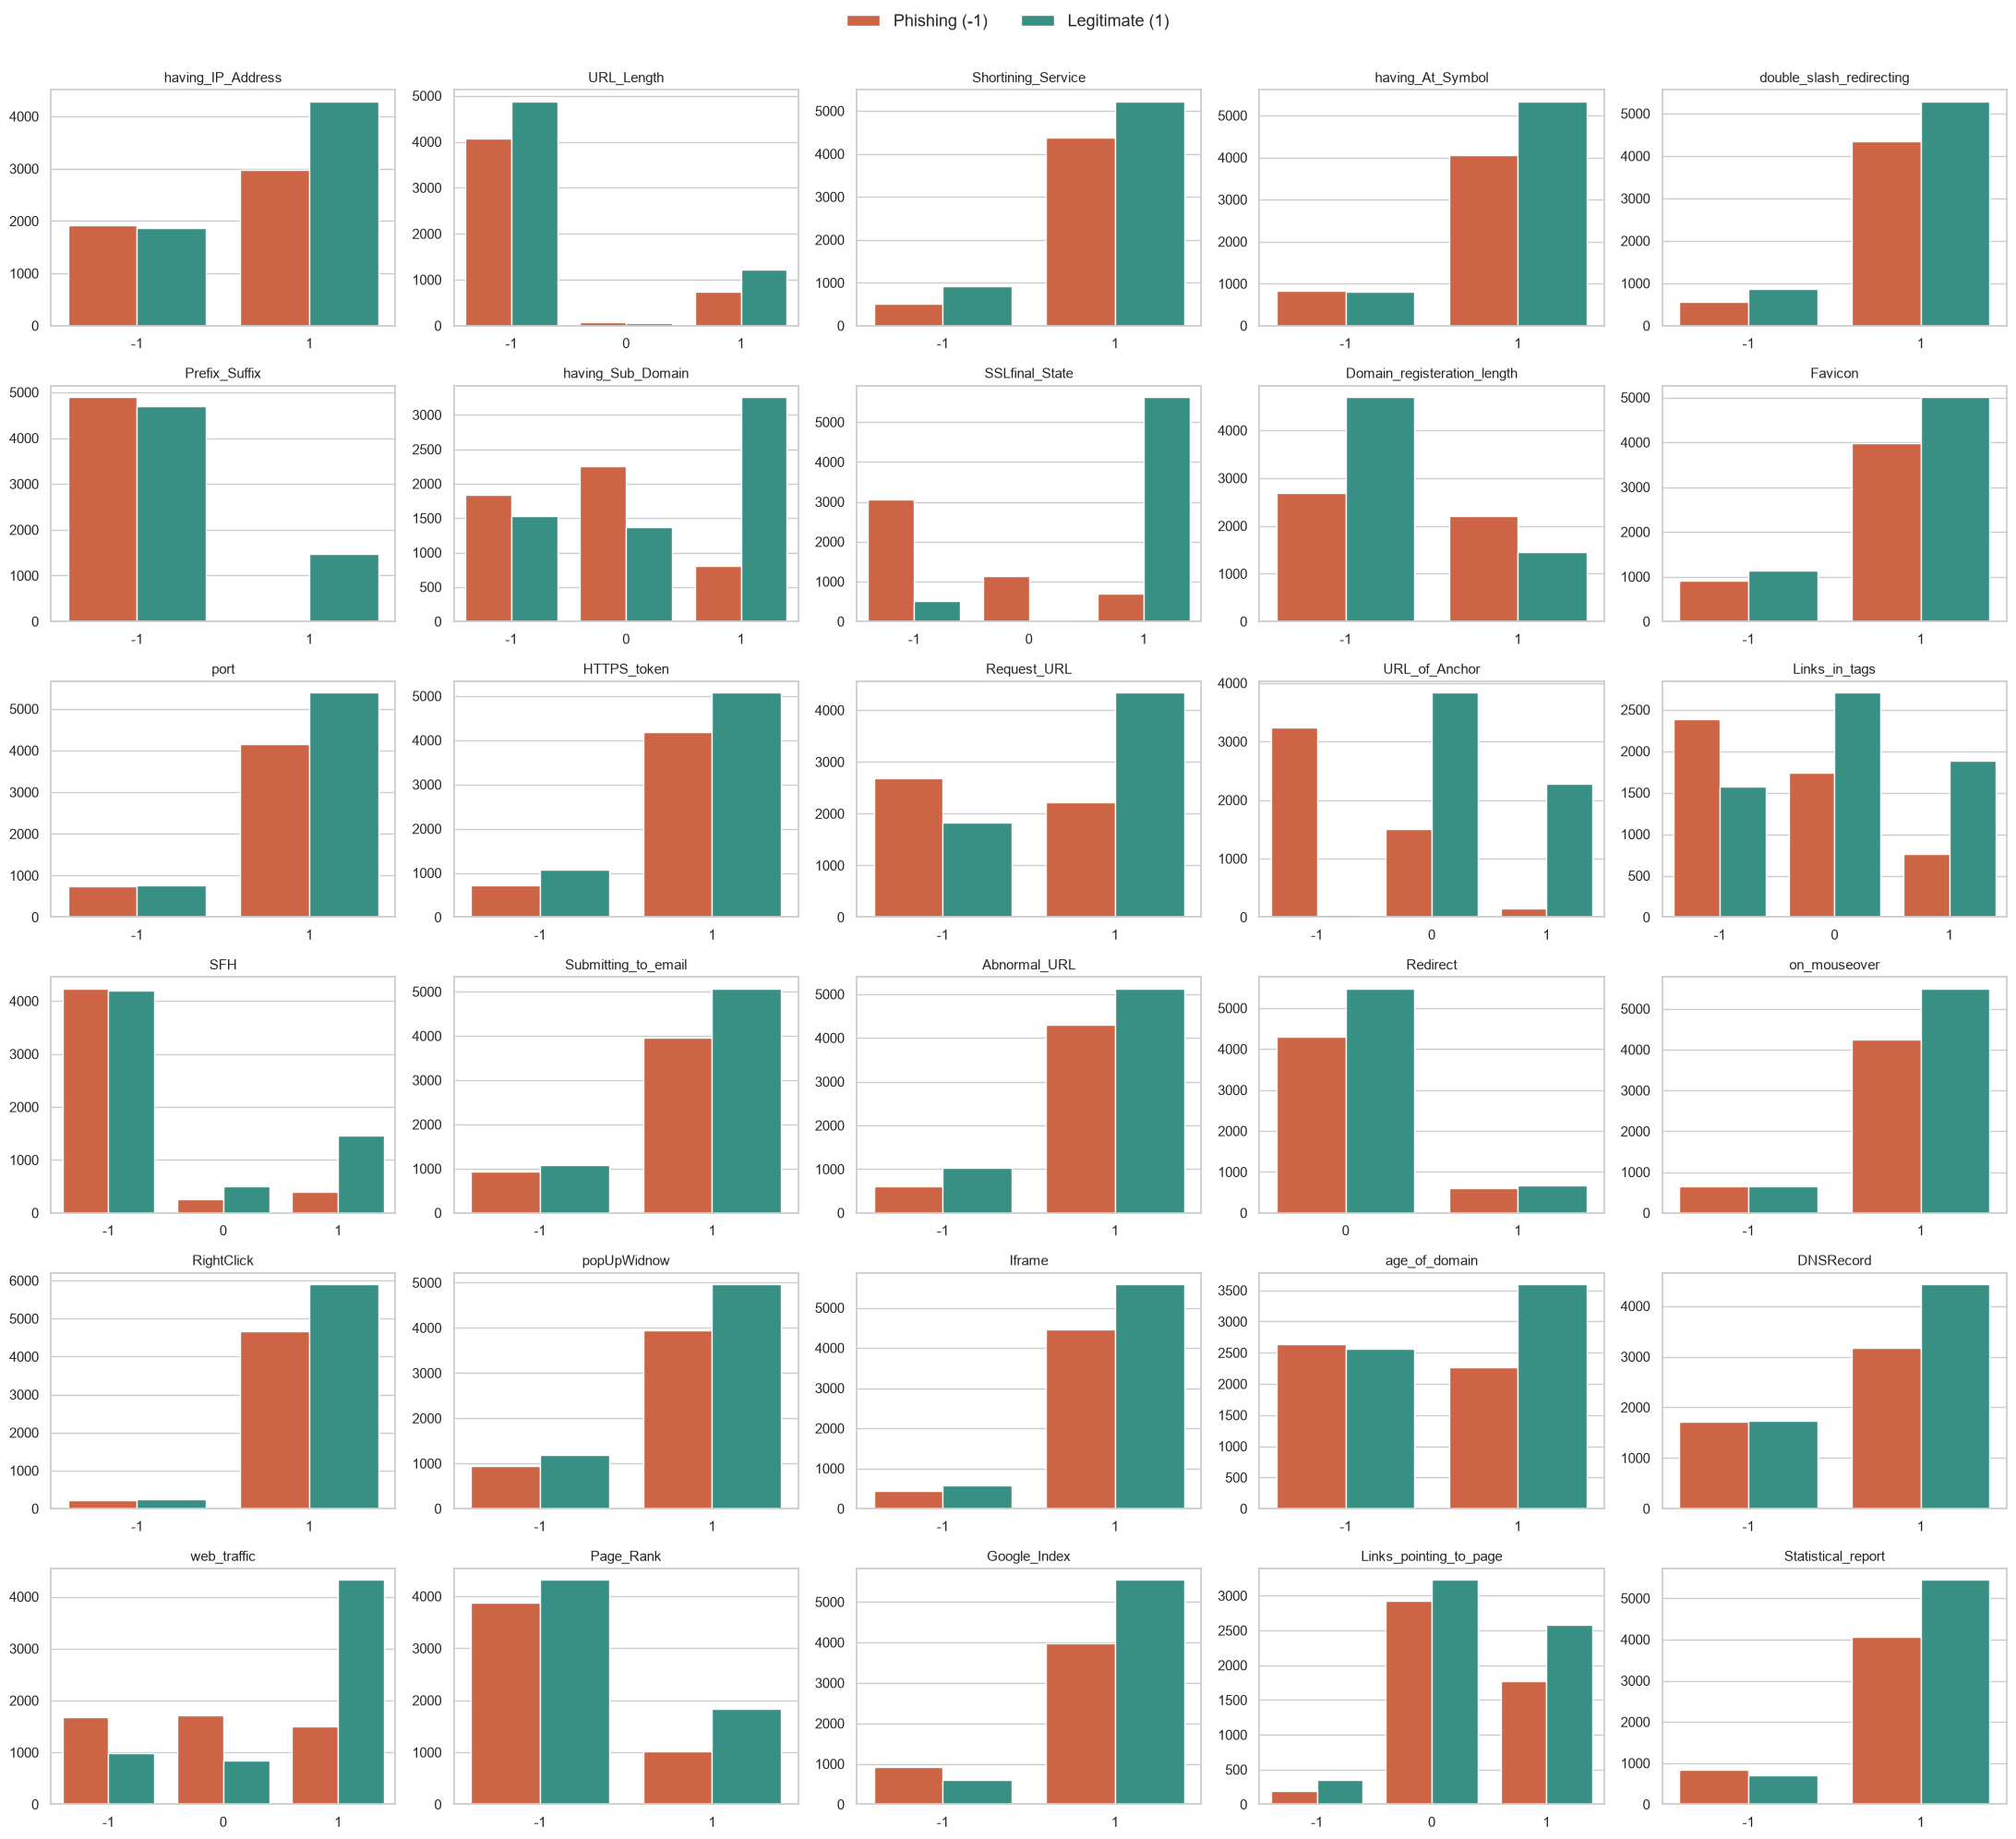

In [16]:
fig, axes = plt.subplots(6, 5, figsize=(22, 20))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.countplot(data=df, x=col, hue="Result", palette=PALETTE, ax=ax)
    ax.set_title(col, fontsize=11); ax.set_xlabel(""); ax.set_ylabel("")
    if ax is axes.ravel()[0]:
        handles, _ = ax.get_legend_handles_labels()
    ax.get_legend().remove()
fig.legend(handles, ["Phishing (-1)", "Legitimate (1)"], loc="upper center", ncol=2, fontsize=13, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

> **What we get:** a very uneven picture.
> * **Clearly informative:** `SSLfinal_State`, `URL_of_Anchor`, `web_traffic`, `having_Sub_Domain`, `Prefix_Suffix` (value `1` occurs almost only for legitimate sites), `Links_in_tags`, `SFH` — red and green bars differ a lot.
> * **Almost useless on their own:** `Favicon`, `popUpWidnow`, `Iframe`, `RightClick`, `port`, `Submitting_to_email` — the red and green bars are nearly the same shape.
> * So we have **a handful of strong features and many weak ones**.

### 7.2 Phishing rate per feature value
**What we do:** for each feature value compute *"of all websites with this value, what % are phishing?"* and show it as a heat-map, sorted by how much the rate changes across values.

**Why:** the count-plots above are affected by how common each value is. The phishing *rate* removes that effect and gives one clean number per value — 0 % (always legitimate) to 100 % (always phishing).

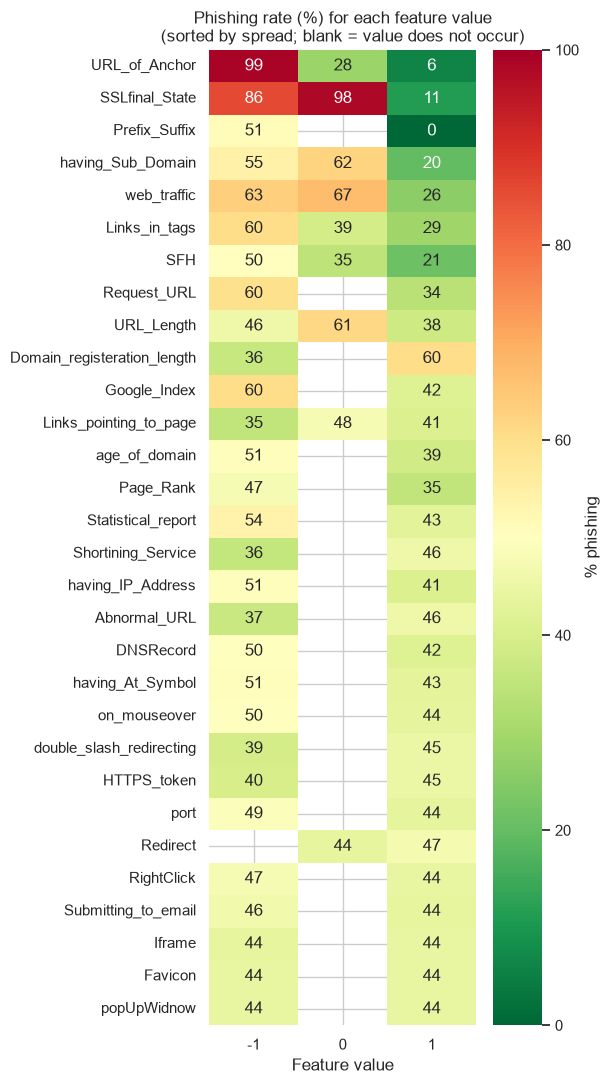

In [17]:
phish_rate = pd.DataFrame(
    {c: df.groupby(c)["Result"].apply(lambda s: (s == -1).mean() * 100) for c in feature_cols}
).T[[-1, 0, 1]]
phish_rate["spread"] = phish_rate[[-1, 0, 1]].max(axis=1) - phish_rate[[-1, 0, 1]].min(axis=1)
phish_rate = phish_rate.sort_values("spread", ascending=False)

fig, ax = plt.subplots(figsize=(6, 11))
sns.heatmap(phish_rate[[-1, 0, 1]], annot=True, fmt=".0f", cmap="RdYlGn_r", vmin=0, vmax=100,
            cbar_kws={"label": "% phishing"}, ax=ax)
ax.set_title("Phishing rate (%) for each feature value\n(sorted by spread; blank = value does not occur)")
ax.set_xlabel("Feature value"); plt.tight_layout(); plt.show()

> **What we get:** the phishing *rate* makes the strongest signals obvious:
> * `URL_of_Anchor = -1` → **99 %** phishing; `= 1` → only **6 %**.
> * `SSLfinal_State = 1` → **11 %** phishing; `= -1` → 86 %.
> * `Prefix_Suffix = 1` → **0 %** phishing.
>
> **Important surprise — the effect is *not monotonic*.** For `SSLfinal_State` the "suspicious" level `0` is **98 %** phishing — *worse* than the "phishing" level `-1` (86 %). The same happens for `URL_Length` (`0`: 61 % vs `-1`: 46 %), `having_Sub_Domain` (`0`: 62 % vs `-1`: 55 %) and `web_traffic` (`0`: 67 % vs `-1`: 63 %). Treating `-1 < 0 < 1` as an evenly spaced number line is therefore wrong for these features — **a strong reason to one-hot encode them for linear / distance-based models.**

## 8. Verifying the coding direction

**What we do:** for every feature check whether value `1` really has a *lower* phishing rate than value `-1`.

**Why:** the dataset description says `1 = legitimate-looking`, but we should never assume. Features where the direction is reversed (or that are useless) are worth knowing about before modelling.

In [18]:
direction = pd.DataFrame({
    "rate_at_-1": phish_rate[-1],
    "rate_at_+1": phish_rate[1],
})
direction["as_documented"] = direction["rate_at_+1"] < direction["rate_at_-1"]
direction["gap_pts"] = (direction["rate_at_-1"] - direction["rate_at_+1"]).round(1)

print("Features where value 1 has a LOWER phishing rate than -1 :", int(direction["as_documented"].sum()), "/", len(direction))
print("\nFeatures that do NOT follow the documented direction (or have no -1 level):")
display(direction[~direction["as_documented"]].round(1))

Features where value 1 has a LOWER phishing rate than -1 : 21 / 30

Features that do NOT follow the documented direction (or have no -1 level):


,rate_at_-1,rate_at_+1,as_documented,gap_pts
Domain_registeration_length,36.4,60.2,False,-23.8
Links_pointing_to_page,35.2,40.8,False,-5.6
Shortining_Service,35.6,45.6,False,-10.0
Abnormal_URL,37.1,45.6,False,-8.5
double_slash_redirecting,39.3,45.0,False,-5.7
HTTPS_token,39.8,45.2,False,-5.4
Redirect,NaN,47.1,False,NaN
Iframe,43.8,44.4,False,-0.6
Favicon,44.3,44.3,False,-0.0


> **What we get:** only **21 of 30** features follow the documented "1 = more legitimate" direction. The rest fall into three groups:
> * **Genuinely reversed:** `Domain_registeration_length` (value `1` is *60 %* phishing vs 36 % at `-1`), and mildly `Shortining_Service`, `Abnormal_URL`, `double_slash_redirecting`, `HTTPS_token`, `Links_pointing_to_page`.
> * **No signal (gap ≈ 0):** `Favicon` and `Iframe` (and `popUpWidnow`, which passes the check only by a hair) — the phishing rate is ~44 % for every value, which is just the base rate.
> * **`Redirect`** only has levels `0` and `1` and is nearly flat.
>
> **Lesson:** never hand-craft rules from the feature documentation — let the models learn the direction from the data.

## 9. How strongly does each feature relate to the target?

**What we do:** score every feature with three complementary measures and rank them.

* **Cramér's V** — strength of association between two *categorical* variables (0 = none, 1 = perfect), based on the chi-square test. Correct choice here because the features are categorical.
* **Mutual information (MI)** — how many "bits" about the target we learn by knowing the feature; also captures non-linear/non-monotonic relations.
* **Pearson r with the target** — signed linear correlation (only meaningful because the codes are ordered `-1 < 0 < 1`); the sign shows the direction.

**Why:** if three different measures agree on the top features, we can trust the ranking. We'll compare it with the model's own importance later.

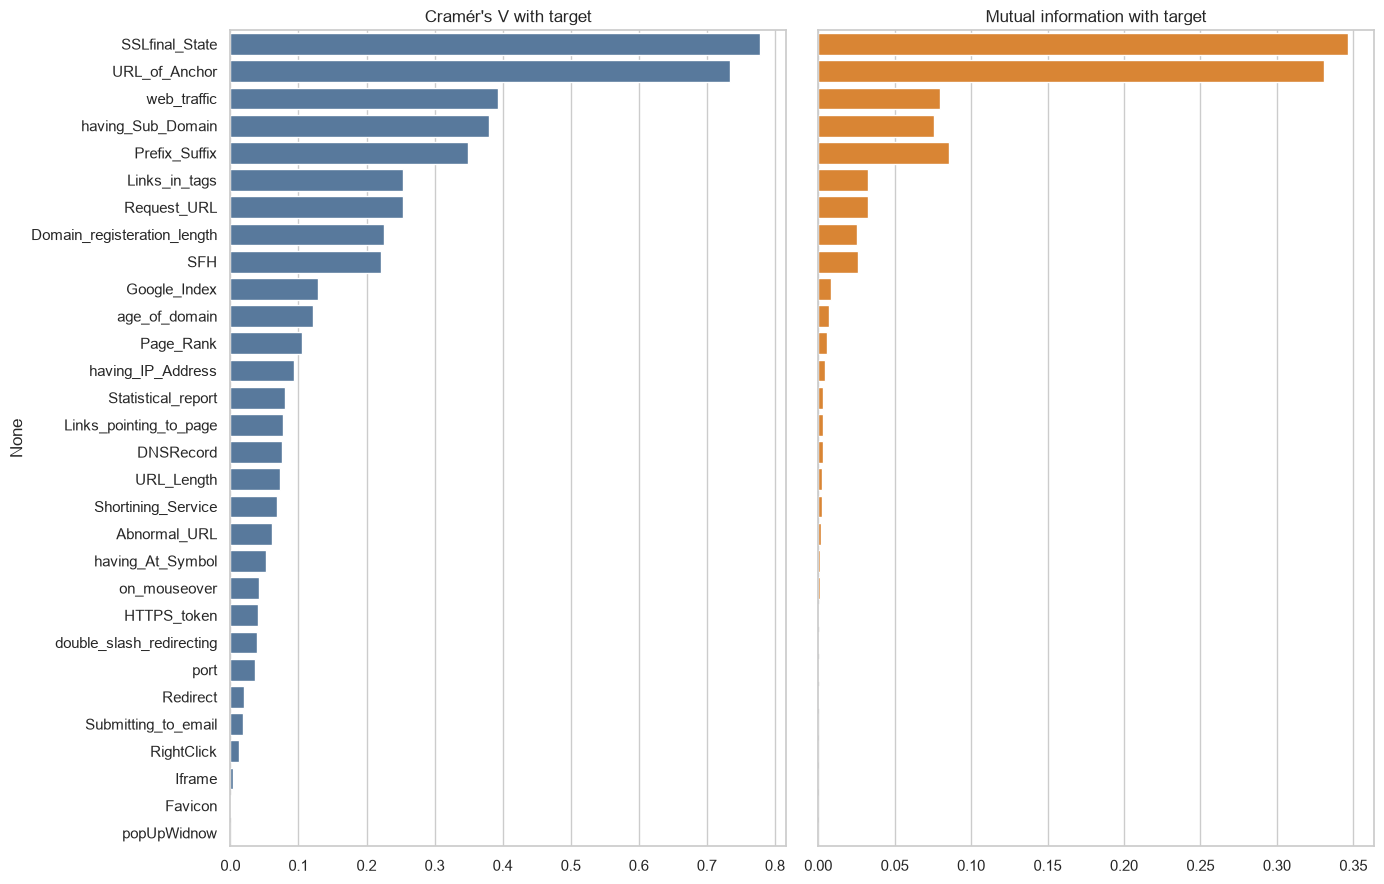

Top 10 features by Cramér's V:


,cramers_v,mutual_info,pearson_r
SSLfinal_State,0.778,0.346,0.715
URL_of_Anchor,0.735,0.331,0.693
web_traffic,0.394,0.079,0.346
having_Sub_Domain,0.380,0.076,0.298
Prefix_Suffix,0.349,0.086,0.349
Links_in_tags,0.254,0.033,0.248
Request_URL,0.253,0.032,0.253
Domain_registeration_length,0.226,0.026,-0.226
SFH,0.222,0.026,0.221
Google_Index,0.129,0.008,0.129


Weakest 8 features:


,cramers_v,mutual_info,pearson_r
double_slash_redirecting,0.039,0.001,-0.039
port,0.036,0.001,0.036
Redirect,0.020,0.000,-0.020
Submitting_to_email,0.018,0.000,0.018
RightClick,0.013,0.000,0.013
Iframe,0.003,0.000,-0.003
Favicon,0.000,0.000,-0.000
popUpWidnow,0.000,0.000,0.000


In [19]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

assoc = pd.DataFrame({
    "cramers_v":   [cramers_v(df[c], df["Result"]) for c in feature_cols],
    "mutual_info": mutual_info_classif(df[feature_cols], df["Result"], discrete_features=True, random_state=42),
    "pearson_r":   df[feature_cols].corrwith(df["Result"]),
}, index=feature_cols).sort_values("cramers_v", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
sns.barplot(x=assoc["cramers_v"], y=assoc.index, color="#4c78a8", ax=axes[0])
axes[0].set_title("Cramér's V with target"); axes[0].set_xlabel("")
sns.barplot(x=assoc["mutual_info"], y=assoc.index, color="#f58518", ax=axes[1])
axes[1].set_title("Mutual information with target"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print("Top 10 features by Cramér's V:")
display(assoc.head(10).round(3))
print("Weakest 8 features:")
display(assoc.tail(8).round(3))

> **What we get:** all three measures agree on the ranking.
> * **Two dominant features:** `SSLfinal_State` (Cramér's V 0.78, MI 0.35) and `URL_of_Anchor` (V 0.74, MI 0.33) — far ahead of everything else.
> * **Second tier (V ≈ 0.35–0.40):** `web_traffic`, `having_Sub_Domain`, `Prefix_Suffix`.
> * **Third tier (V ≈ 0.2–0.25):** `Links_in_tags`, `Request_URL`, `Domain_registeration_length`, `SFH`.
> * **Practically zero association:** `popUpWidnow`, `Favicon`, `Iframe`, `RightClick`, `Submitting_to_email`, `Redirect` (V ≤ 0.02).
> * `Domain_registeration_length` has a **negative** Pearson r (−0.23), confirming the reversed direction found above.
>
> Later we'll check whether the trained model's importance ranking agrees with this one.

## 10. Correlation between features (redundancy)

**What we do:** compute the correlation matrix of all columns, draw it as a heat-map (lower triangle) and list the most strongly correlated *feature pairs*.

**Why:** highly correlated features carry overlapping information. That matters for linear models (unstable coefficients) but is mostly harmless for tree ensembles. It also tells us whether dimensionality reduction/feature removal is really needed. Pearson on ordinal codes is only an approximation, but it is good enough for a quick redundancy check.

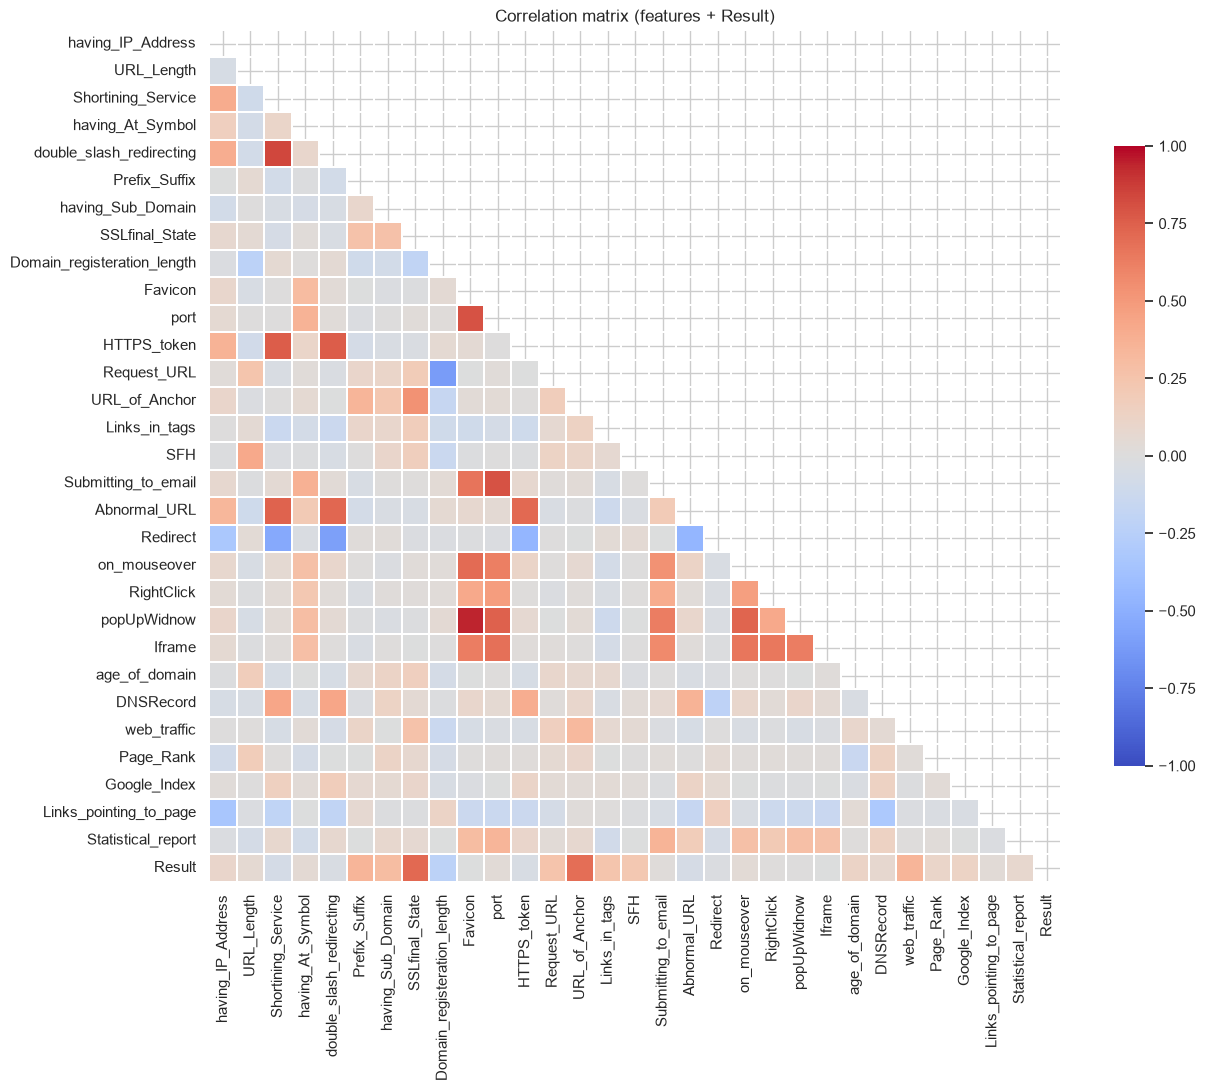

Strongest feature-feature correlations:


,feature_1,feature_2,corr,abs_corr
0,Favicon,popUpWidnow,0.940,0.940
1,Shortining_Service,double_slash_redirecting,0.843,0.843
2,Favicon,port,0.804,0.804
3,port,Submitting_to_email,0.799,0.799
4,double_slash_redirecting,HTTPS_token,0.761,0.761
5,Shortining_Service,HTTPS_token,0.758,0.758
6,port,popUpWidnow,0.749,0.749
7,Shortining_Service,Abnormal_URL,0.739,0.739
8,on_mouseover,popUpWidnow,0.734,0.734
9,double_slash_redirecting,Abnormal_URL,0.724,0.724


Pairs with |r| > 0.5: 26 | pairs with |r| > 0.7: 12


In [20]:
corr_all = df.corr()
mask = np.triu(np.ones_like(corr_all, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_all, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation matrix (features + Result)")
plt.tight_layout(); plt.show()

corr_feat = df[feature_cols].corr()
pairs = (corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))
                  .stack().rename("corr").reset_index())
pairs.columns = ["feature_1", "feature_2", "corr"]
pairs["abs_corr"] = pairs["corr"].abs()
print("Strongest feature-feature correlations:")
display(pairs.sort_values("abs_corr", ascending=False).head(10).round(3).reset_index(drop=True))
print("Pairs with |r| > 0.5:", int((pairs["abs_corr"] > 0.5).sum()), "| pairs with |r| > 0.7:", int((pairs["abs_corr"] > 0.7).sum()))

> **What we get:** the features are far from independent — **26 feature pairs have |r| > 0.5 and 12 pairs |r| > 0.7**. The strongest: `Favicon`–`popUpWidnow` (0.94), `Shortining_Service`–`double_slash_redirecting` (0.84), `Favicon`–`port` (0.80), `port`–`Submitting_to_email` (0.80).
>
> Note that these redundant features are mostly the **weak** ones from Section 9 — they are strongly correlated *with each other* but barely with the target. Implications: (1) tree ensembles are robust to this; (2) linear models need regularisation; (3) removing several of these weak features would lose little information — we can test that with feature importance later.

## 11. Duplicates — a hidden risk for model evaluation

**What we do:** (a) see which class the duplicates belong to, (b) count *conflicting* patterns — identical feature values that appear with **both** labels.

**Why:** all features are low-cardinality codes, so many websites end up with exactly the same feature vector. If duplicates stay in the data, a random train/test split will put the *same row* on both sides, and the model gets credit for simply memorising it. Conflicting patterns show us the **noise ceiling** — no model can be 100 % accurate if the same input has two different answers.

In [21]:
dups = df[df.duplicated()]
print("Duplicated rows by class:")
print(dups["Result"].map(LABELS).value_counts().to_string())

unique_df = df.drop_duplicates()
print(f"\nAfter dropping exact duplicates: {len(unique_df):,} rows")
print((unique_df["Result"].map(LABELS).value_counts(normalize=True) * 100).round(1).to_string())

labels_per_pattern = unique_df.groupby(feature_cols)["Result"].nunique()
n_patterns = len(labels_per_pattern)
n_conflict = int((labels_per_pattern > 1).sum())
print(f"\nDistinct feature patterns          : {n_patterns:,}")
print(f"Patterns that appear with BOTH labels: {n_conflict}  ({n_conflict / n_patterns:.1%})")

Duplicated rows by class:
Result
Legitimate    3327
Phishing      1879

After dropping exact duplicates: 5,849 rows
Result
Phishing      51.6
Legitimate    48.4

Distinct feature patterns          : 5,785
Patterns that appear with BOTH labels: 64  (1.1%)


> **What we get:**
> * Duplicates are not evenly spread: **3,327 legitimate vs 1,879 phishing** rows. After removing them, the class ratio shifts from 44 % / 56 % (phishing / legitimate) to **51.6 % / 48.4 %** — so the original file over-represents legitimate sites through repetition.
> * Of 5,785 distinct feature patterns, **64 (1.1 %) appear with both labels**. These are genuinely ambiguous inputs (the 30 features cannot tell them apart), so no model can reach 100 % — but the ceiling is high.
>
> **Decision for modelling:** drop exact duplicates *before* the train/test split. Otherwise the same row lands in both sets and the test score becomes over-optimistic. The model notebook demonstrates this effect with an experiment.

## 12. A simple "suspicion score"

**What we do:** add up all 30 feature values for each website (a crude score: higher = more legitimate-looking signals, lower = more phishing signals) and compare its distribution for the two classes.

**Why:** if even this naive, unweighted sum separates the classes well, it tells us the signal is spread across *many* features (good for ensembles) and that a well-trained model should reach high accuracy.

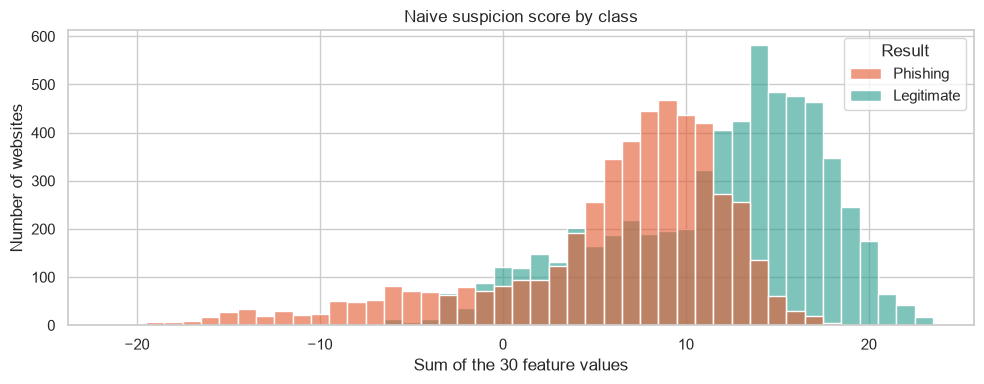

             mean   std   min   50%   max
Result                                   
Legitimate  11.66  5.95 -10.0  13.0  23.0
Phishing     5.93  6.72 -21.0   8.0  20.0


In [22]:
score = df[feature_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(x=score, hue=df["Result"].map(LABELS), discrete=True, palette=PALETTE_NAMES,
             multiple="layer", alpha=0.6, ax=ax)
ax.set_xlabel("Sum of the 30 feature values"); ax.set_ylabel("Number of websites")
ax.set_title("Naive suspicion score by class")
plt.tight_layout(); plt.show()

print(score.groupby(df["Result"].map(LABELS)).describe().round(2)[["mean", "std", "min", "50%", "max"]])

> **What we get:** legitimate sites have a clearly higher average score (**mean 11.7, median 13**) than phishing sites (**mean 5.9, median 8**), so the signals do point in the same overall direction. But the two histograms **overlap heavily** (standard deviations ≈ 6), so an unweighted sum alone is a poor classifier. Learned weights and interactions between features are needed — which is exactly what machine-learning models provide.

## 13. PCA — how separable is the data in 2-D?

**What we do:** project the (de-duplicated) 30-dimensional data onto its first two principal components, colour by class, and plot how much variance each component explains.

**Why:** a quick visual test of class separability, and a check on whether the information is concentrated in a few directions (then we could reduce dimensionality) or spread out. Points are jittered slightly because the data is discrete and many rows would otherwise sit on top of each other.

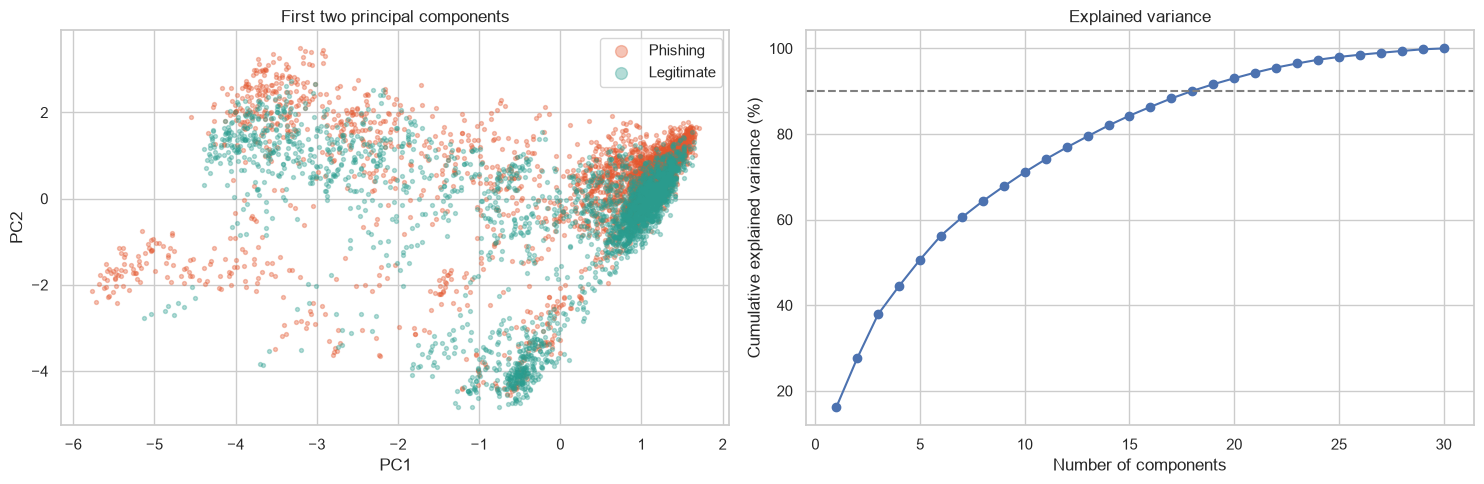

PC1 + PC2 explain 27.6% of the variance
Components needed for 90% of the variance: 18 of 30


In [23]:
X_u, y_u = unique_df[feature_cols], unique_df["Result"]

pca_full = PCA(random_state=42).fit(X_u)
Z = pca_full.transform(X_u)[:, :2]
Z = Z + np.random.default_rng(42).normal(0, 0.06, Z.shape)     # jitter for visibility

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for cls in (-1, 1):
    m = (y_u == cls).values
    axes[0].scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.35, c=PALETTE[cls], label=LABELS[cls])
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(markerscale=3)
axes[0].set_title("First two principal components")

cum = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cum) + 1), cum, marker="o")
axes[1].axhline(90, ls="--", c="grey"); axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Explained variance")
plt.tight_layout(); plt.show()

print(f"PC1 + PC2 explain {cum[1]:.1f}% of the variance")
print(f"Components needed for 90% of the variance: {int(np.argmax(cum >= 90)) + 1} of {len(cum)}")

> **What we get:**
> * The two classes **overlap a lot in 2-D**; only some regions are class-pure (e.g. a dense legitimate cluster at the bottom, phishing points on the far left). The classes are not linearly separable in this projection.
> * PC1 + PC2 explain only **27.6 %** of the variance and **18 of 30 components** are needed for 90 % → the information is spread across many features; there is **no compact low-dimensional structure**, so PCA-based dimensionality reduction would not help much. We'll skip PCA and rely on the models themselves (and optionally feature selection).

## 14. Feature interaction — the two strongest features together

**What we do:** take the two features with the highest Cramér's V and show the phishing rate (and the number of websites) for every combination of their values.

**Why:** models do not look at features one at a time. This shows how much extra certainty we get from combining two signals — and gives an intuition for why tree-based models tend to work well here.

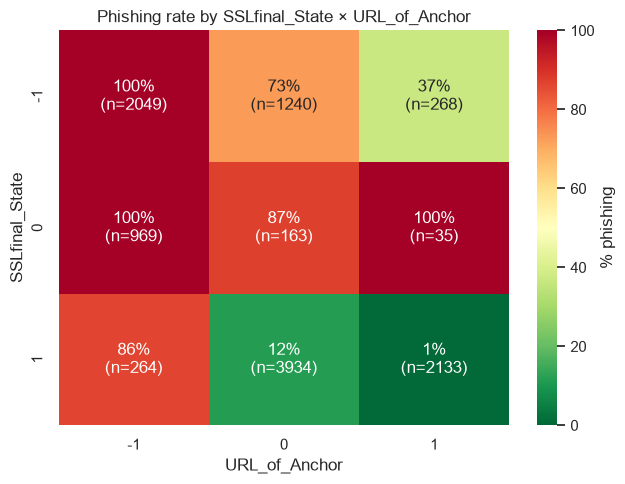

: 

In [ ]:
f1, f2 = assoc.index[:2]
rate = df.pivot_table(index=f1, columns=f2, values="Result", aggfunc=lambda s: (s == -1).mean() * 100)
size = df.pivot_table(index=f1, columns=f2, values="Result", aggfunc="size")
annot = rate.round(0).astype(int).astype(str) + "%\n(n=" + size.astype(int).astype(str) + ")"

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(rate, annot=annot, fmt="", cmap="RdYlGn_r", vmin=0, vmax=100, cbar_kws={"label": "% phishing"}, ax=ax)
ax.set_title(f"Phishing rate by {f1} × {f2}")
plt.tight_layout(); plt.show()

> **What we get:** combining the two best features gives much sharper predictions than either alone, and shows **interactions**:
> * `URL_of_Anchor = -1` with `SSLfinal_State` of `-1` or `0` → **100 % phishing** (n = 2,049 and 969).
> * `SSLfinal_State = 1` **and** `URL_of_Anchor = 1` → only **1 %** phishing (n = 2,133).
> * The effect of one feature depends on the other: `SSLfinal_State = -1` is 86 % phishing overall, but only **37 %** when `URL_of_Anchor = 1` (a small group, n = 268); and a valid SSL (`1`) is still **86 % phishing** when `URL_of_Anchor = -1`.
>
> Such "if A and B then …" rules are exactly what decision trees, random forests and boosting learn naturally, so we expect these to perform very well.

## 15. Summary — what we learned and what we will do about it

| # | Finding | Evidence | Decision for the model-training notebook |
|:-:|---|---|---|
| 1 | Data is clean except for **massive duplication** (47 % of rows) | Section 3.2 & 11 | **Drop duplicates before splitting** to avoid train/test leakage; show the effect with an experiment |
| 2 | Classes are only mildly unbalanced (44 % / 56 %; 52 % / 48 % after de-duplication) | Section 5 & 11 | No resampling; **stratified** split & CV; evaluate with accuracy, precision, recall, F1, ROC-AUC |
| 3 | All features are **categorical codes**, and several have **non-monotonic** effects (e.g. `SSLfinal_State = 0` is worse than `-1`) | Section 4 & 7.2 | Use **raw codes for tree models** and **one-hot encoding for linear / KNN / SVM / NN** models; compare both empirically |
| 4 | **Two dominant features** (`SSLfinal_State`, `URL_of_Anchor`), a middle tier, and a long tail of near-useless features | Section 9 | Expect strong models; check permutation importance and optionally feature pruning |
| 5 | **Strong feature interactions** | Section 14 | Tree ensembles / boosting should shine; include several families of models for a fair comparison |
| 6 | Weak features are **highly inter-correlated** | Section 10 | Regularisation for linear models; trees are unaffected |
| 7 | Documented "1 = legitimate" direction is **not reliable** (9 of 30 features deviate) | Section 8 | Do **no** hand-made rules; let models learn |
| 8 | **No low-dimensional structure** (18 PCs for 90 % variance) | Section 13 | Skip PCA |
| 9 | ~1 % of feature patterns are ambiguous (both labels) | Section 11 | Expect a very high, but not perfect, accuracy ceiling |

**Next step:** open `02_model_training.ipynb` — clean the data, encode features, compare many models with cross-validation, tune hyper-parameters, build ensembles and evaluate the winner on a held-out test set.